#  Exploratory Data Analysis (EDA) — HAM10000 Skin Cancer Dataset
### Skin Cancer Detection ML Project  |  Colab-Style Notebook
---
> **Author:** Skin Cancer Detection ML Project  
> **Dataset:** HAM10000 — Human Against Machine with 10000 training images  
> **Task:** Binary Classification — **Benign (0)** vs **Malignant (1)**

---
##  Notebook Overview
In this notebook we perform a thorough **Exploratory Data Analysis** on the HAM10000 dataset.

###  Disease Classes (7 Categories  Binary Target)
| Code | Full Name | Label |
|------|-----------|-------|
| `nv` | Melanocytic nevi | **Benign (0)** |
| `bkl` | Benign keratosis-like lesions | **Benign (0)** |
| `vasc` | Vascular lesions | **Benign (0)** |
| `df` | Dermatofibroma | **Benign (0)** |
| `mel` | Melanoma | **Malignant (1)** |
| `bcc` | Basal cell carcinoma | **Malignant (1)** |
| `akiec` | Actinic keratoses / Intraepithelial carcinoma | **Malignant (1)** |

###  Sections
1. Setup and Libraries
2. Load Metadata and Map Image Paths
3. Binary Label Mapping (Benign vs Malignant)
4. Dataset Overview and Basic Statistics
5. Distribution Visualizations
6. Missing Value Analysis
7. Correlation Analysis
8. Sample Image Visualization
9. Image Size Statistics
10. Key Findings Summary


---
## 1.  Setup and Libraries


In [18]:
#  Install/check libraries (uncomment on Colab) 
# !pip install pandas numpy matplotlib seaborn pillow opencv-python scikit-learn

import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

#  Plotting style 
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100
})

print('[OK] All libraries imported successfully!')
print(f'   numpy  : {np.__version__}')
print(f'   pandas : {pd.__version__}')


[OK] All libraries imported successfully!
   numpy  : 2.4.6
   pandas : 3.0.3


---
## 2.  Load Metadata and Map Image Paths


In [19]:
#  Paths 
import os
import glob
import pandas as pd

# Detect if running in Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print('Running in Google Colab!')
    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')
    
    # Metadata path (defaults to current folder /content/HAM10000_metadata.csv)
    METADATA_PATH = 'HAM10000_metadata.csv'
    if not os.path.exists(METADATA_PATH):
        METADATA_PATH = '/content/HAM10000_metadata.csv'
    
    # Default images folder in Google Drive (Google Drive root/MyDrive)
    # Update this if you put your images in a subfolder like '/content/drive/MyDrive/SkinCancerData'
    IMAGES_DIR = '/content/drive/MyDrive'
else:
    # Local path resolution
    wsl_path = os.path.expanduser('~/data/HAM10000_metadata.csv')
    if os.path.exists(wsl_path):
        METADATA_PATH = wsl_path
        IMAGES_DIR    = os.path.expanduser('~/data')
    elif os.path.exists('data/HAM10000_metadata.csv'):
        METADATA_PATH = 'data/HAM10000_metadata.csv'
        IMAGES_DIR    = 'data'
    elif os.path.exists('../data/HAM10000_metadata.csv'):
        METADATA_PATH = '../data/HAM10000_metadata.csv'
        IMAGES_DIR    = '../data'
    else:
        METADATA_PATH = '../data/HAM10000_metadata.csv'
        IMAGES_DIR    = '../data'

print(f'Metadata Path: {METADATA_PATH}')
print(f'Images Directory: {IMAGES_DIR}')

#  Load CSV 
df = pd.read_csv(METADATA_PATH)
print(f'Metadata loaded   shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()


Metadata Path: /home/shan_ahmedshani/data/HAM10000_metadata.csv
Images Directory: /home/shan_ahmedshani/data
Metadata loaded   shape: (10015, 7)
Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [20]:
#  Map image IDs to file paths 
# HAM10000 images are split across two part folders
image_paths = []
part1_path = os.path.join(IMAGES_DIR, 'HAM10000_images_part_1')
part2_path = os.path.join(IMAGES_DIR, 'HAM10000_images_part_2')

if os.path.exists(part1_path):
    image_paths.extend(glob.glob(os.path.join(part1_path, '*.jpg')))
if os.path.exists(part2_path):
    image_paths.extend(glob.glob(os.path.join(part2_path, '*.jpg')))

# If no images found in the part folders, check the base directory itself
if len(image_paths) == 0:
    image_paths.extend(glob.glob(os.path.join(IMAGES_DIR, '*.jpg')))

# Last resort: recursive scan, with a warning if running in Colab on the root Drive folder
if len(image_paths) == 0:
    if IN_COLAB and IMAGES_DIR == '/content/drive/MyDrive':
        print('[WARNING] Scanning the entire Google Drive recursively might be very slow!')
        print('          Consider creating a specific folder for images and updating IMAGES_DIR.')
    image_paths.extend(glob.glob(os.path.join(IMAGES_DIR, '**', '*.jpg'), recursive=True))

# Remove duplicates
image_path_dict = {os.path.splitext(os.path.basename(p))[0]: p for p in image_paths}
print(f'Total unique image files found: {len(image_path_dict)}')

df['path'] = df['image_id'].map(image_path_dict.get)

missing = df['path'].isna().sum()
print(f'Entries missing image files  : {missing}')
print(f'Entries with images          : {df["path"].notna().sum()}')


Total unique image files found: 10015
Entries missing image files  : 0
Entries with images          : 10015


---
## 3.  Binary Label Mapping (Benign vs Malignant)


In [21]:
#  Full cell type names 
lesion_type_dict = {
    'nv'   : 'Melanocytic nevi',
    'mel'  : 'Melanoma',
    'bkl'  : 'Benign keratosis-like lesions',
    'bcc'  : 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc' : 'Vascular lesions',
    'df'   : 'Dermatofibroma'
}

#  Binary mapping: 0 = Benign, 1 = Malignant 
lesion_danger = {
    'nv'   : 0,  # Benign
    'mel'  : 1,  # Malignant 
    'bkl'  : 0,  # Benign
    'bcc'  : 1,  # Malignant 
    'akiec': 1,  # Malignant 
    'vasc' : 0,  # Benign
    'df'   : 0   # Benign
}

df['cell_type']    = df['dx'].map(lesion_type_dict)
df['target']       = df['dx'].map(lesion_danger)
df['target_name']  = df['target'].map({0: 'Benign', 1: 'Malignant'})
df['cell_type_idx'] = pd.Categorical(df['cell_type']).codes

print('Columns after mapping:')
print(df[['image_id', 'dx', 'cell_type', 'target', 'target_name']].head(8).to_string())


Columns after mapping:
       image_id   dx                      cell_type  target target_name
0  ISIC_0027419  bkl  Benign keratosis-like lesions       0      Benign
1  ISIC_0025030  bkl  Benign keratosis-like lesions       0      Benign
2  ISIC_0026769  bkl  Benign keratosis-like lesions       0      Benign
3  ISIC_0025661  bkl  Benign keratosis-like lesions       0      Benign
4  ISIC_0031633  bkl  Benign keratosis-like lesions       0      Benign
5  ISIC_0027850  bkl  Benign keratosis-like lesions       0      Benign
6  ISIC_0029176  bkl  Benign keratosis-like lesions       0      Benign
7  ISIC_0029068  bkl  Benign keratosis-like lesions       0      Benign


---
## 4.  Dataset Overview and Basic Statistics


In [22]:
print('=' * 60)
print('  DATASET OVERVIEW')
print('=' * 60)
print(f'  Total samples : {len(df)}')
print(f'  Benign (0)    : {(df["target"] == 0).sum()}  ({(df["target"] == 0).mean()*100:.1f}%)')
print(f'  Malignant (1) : {(df["target"] == 1).sum()}  ({(df["target"] == 1).mean()*100:.1f}%)')
print('=' * 60)
print('\nClass distribution by dx code:')
print(df['dx'].value_counts().to_string())
print('\nData types:')
print(df.dtypes)


  DATASET OVERVIEW
  Total samples : 10015
  Benign (0)    : 8061  (80.5%)
  Malignant (1) : 1954  (19.5%)

Class distribution by dx code:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115

Data types:
lesion_id            str
image_id             str
dx                   str
dx_type              str
age              float64
sex                  str
localization         str
path                 str
cell_type            str
target             int64
target_name          str
cell_type_idx       int8
dtype: object


In [23]:
#  Descriptive statistics 
print('\nDescriptive Statistics:')
df[['age', 'target']].describe()



Descriptive Statistics:


,age,target
count,9958.000000,10015.000000
mean,51.863828,0.195107
std,16.968614,0.396303
min,0.000000,0.000000
25%,40.000000,0.000000
50%,50.000000,0.000000
75%,65.000000,0.000000
max,85.000000,1.000000


---
## 5.  Distribution Visualizations


### 5.1 Benign vs Malignant — Target Class Distribution


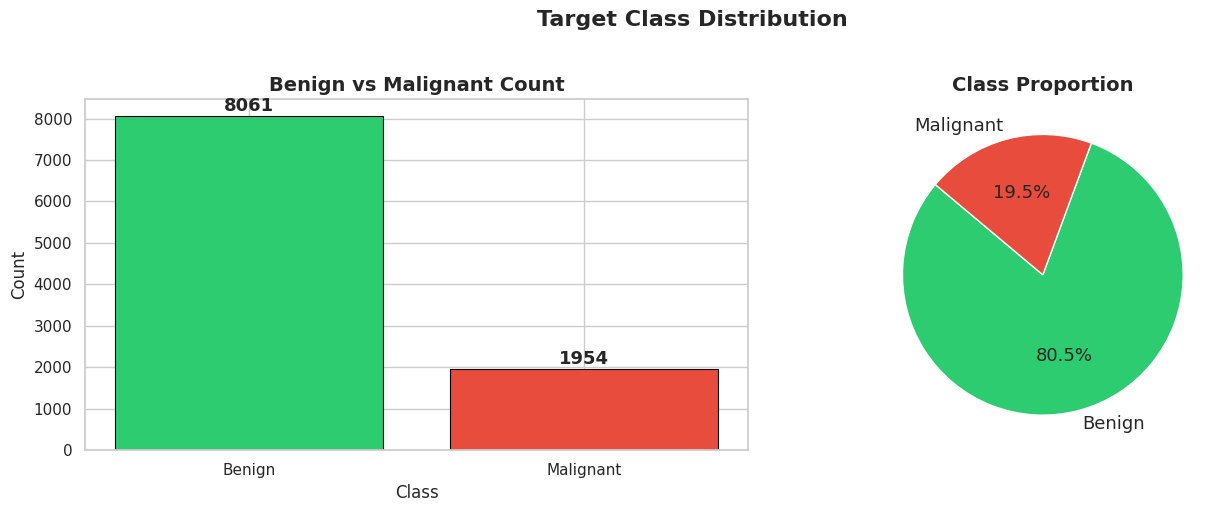

[WARN]  Class imbalance detected: Benign >> Malignant


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = df['target_name'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(val), ha='center', va='bottom', fontweight='bold', fontsize=13)
axes[0].set_title('Benign vs Malignant Count', fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=140,
            textprops={'fontsize': 13})
axes[1].set_title('Class Proportion', fontweight='bold')

plt.suptitle('Target Class Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('[WARN]  Class imbalance detected: Benign >> Malignant')


### 5.2 Distribution of 7 Original Lesion Types


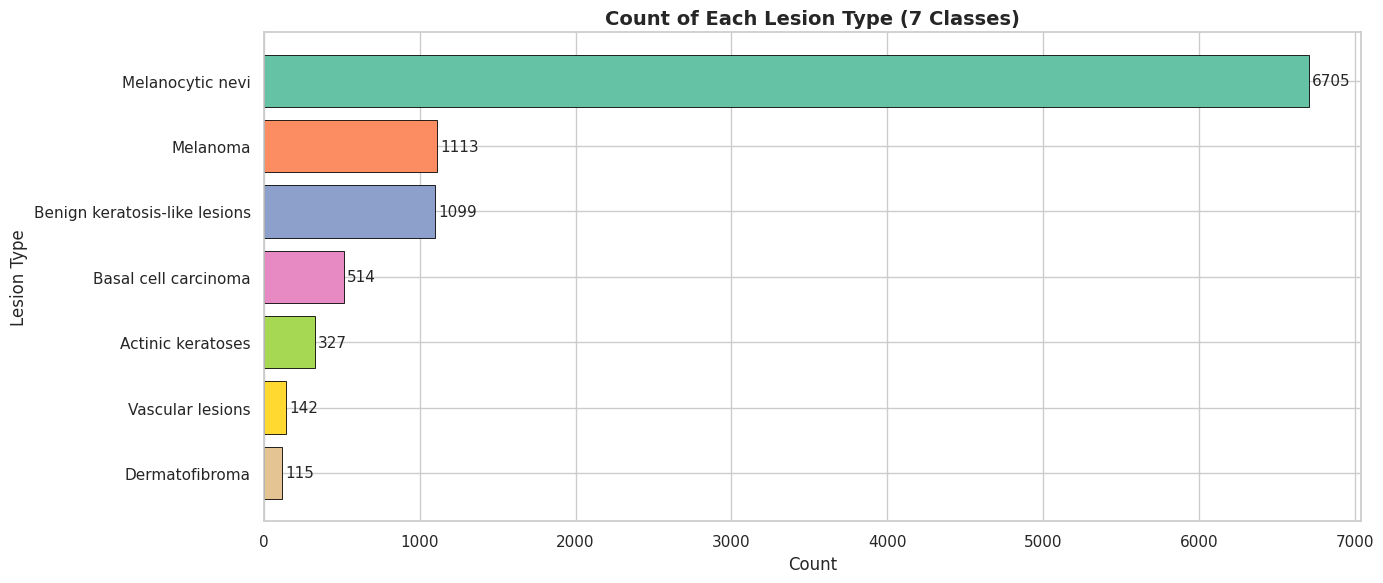

In [25]:
fig, ax = plt.subplots(figsize=(14, 6))

order = df['cell_type'].value_counts().index
palette = sns.color_palette('Set2', n_colors=7)

barplot = sns.barplot(y='cell_type', x='cell_type', data=df,
                      order=order, palette=palette,
                      estimator=lambda x: len(x), ax=ax)

# Better approach: use countplot
ax.cla()
counts_by_type = df['cell_type'].value_counts()
bars = ax.barh(counts_by_type.index, counts_by_type.values, color=palette, edgecolor='black', linewidth=0.6)
for bar, val in zip(bars, counts_by_type.values):
    ax.text(val + 20, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=11)
ax.set_title('Count of Each Lesion Type (7 Classes)', fontweight='bold', fontsize=14)
ax.set_xlabel('Count')
ax.set_ylabel('Lesion Type')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 5.3 Demographic Distributions: Gender, Age, Localization


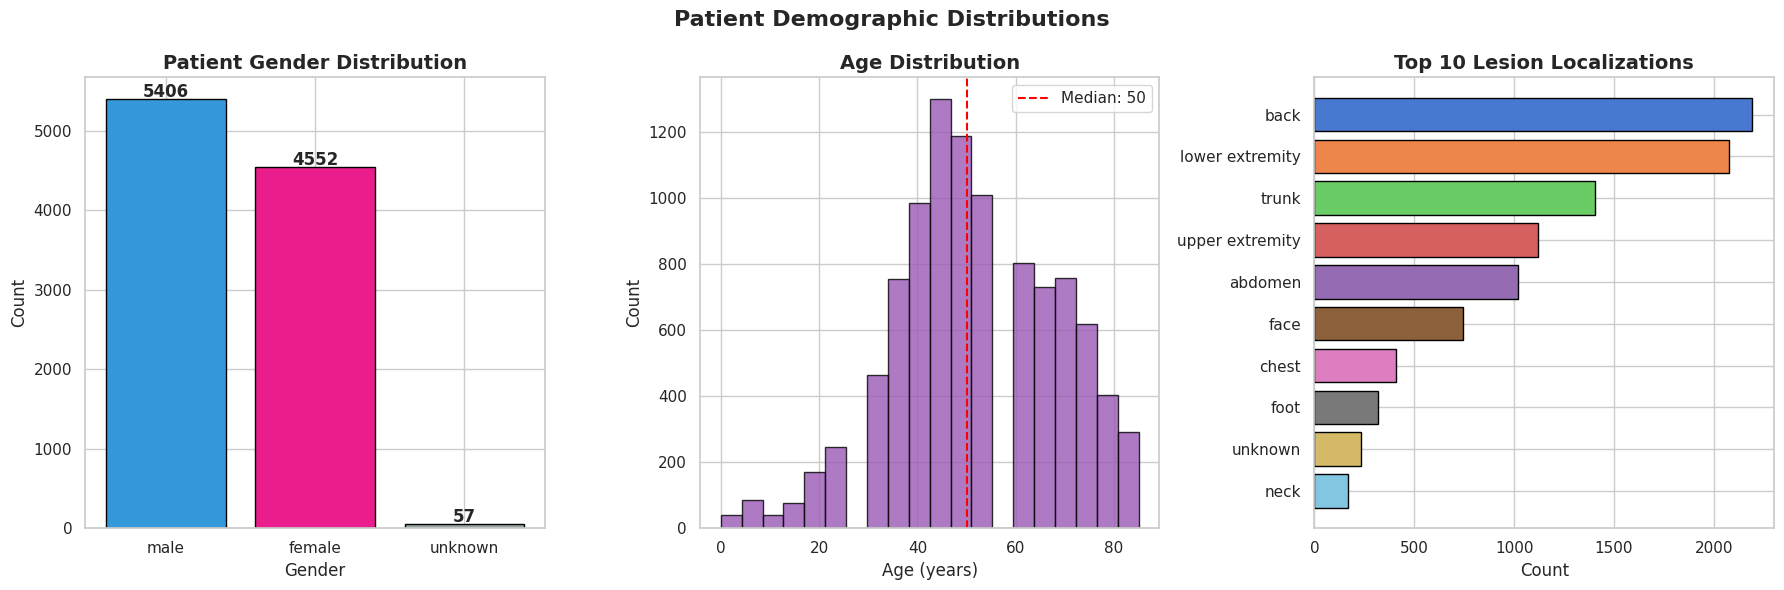

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gender
gender_counts = df['sex'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values,
            color=['#3498db', '#e91e8c', '#95a5a6'], edgecolor='black')
axes[0].set_title('Patient Gender Distribution', fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Age distribution
df['age'].hist(bins=20, ax=axes[1], color='#9b59b6', edgecolor='black', alpha=0.8)
axes[1].set_title('Age Distribution', fontweight='bold')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Count')
axes[1].axvline(df['age'].median(), color='red', linestyle='--', label=f'Median: {df["age"].median():.0f}')
axes[1].legend()

# Localization
loc_counts = df['localization'].value_counts().head(10)
axes[2].barh(loc_counts.index, loc_counts.values,
             color=sns.color_palette('muted', n_colors=10), edgecolor='black')
axes[2].set_title('Top 10 Lesion Localizations', fontweight='bold')
axes[2].set_xlabel('Count')
axes[2].invert_yaxis()

plt.suptitle('Patient Demographic Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.4 Age Distribution by Target Class


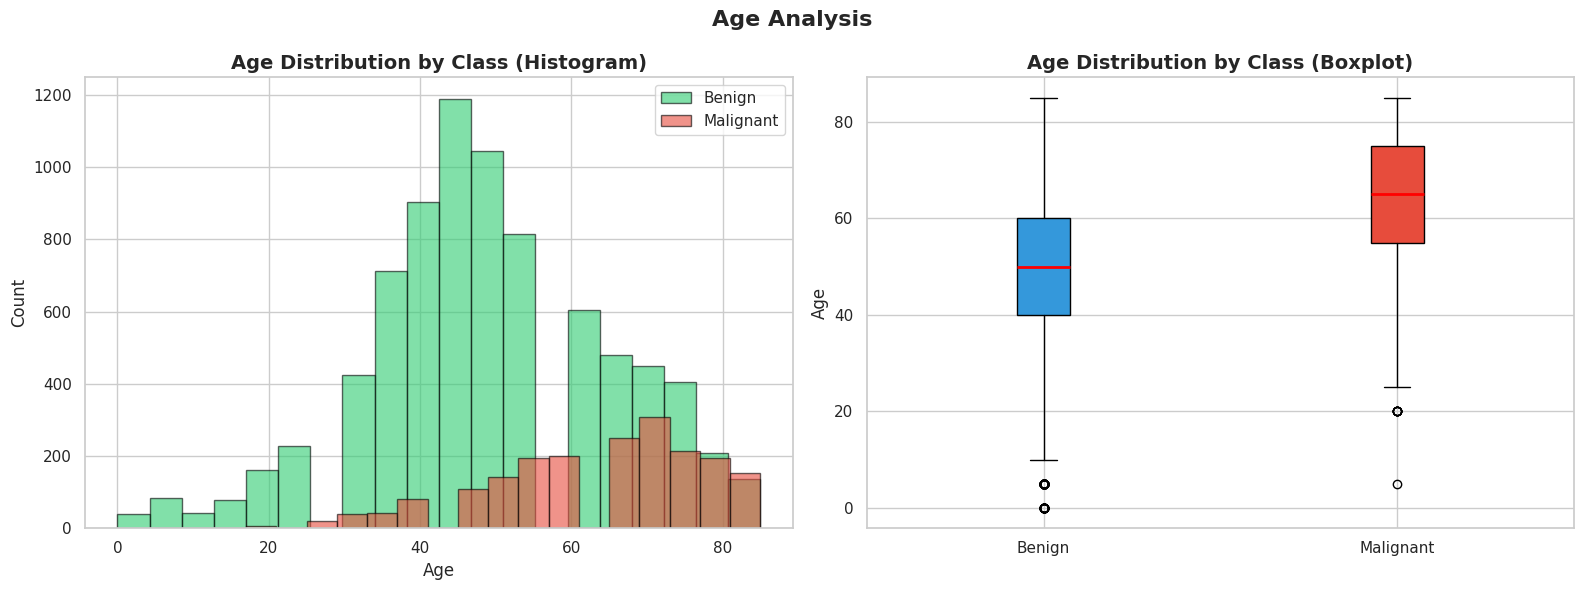

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram with KDE
for label, color in zip(['Benign', 'Malignant'], ['#2ecc71', '#e74c3c']):
    subset = df[df['target_name'] == label]['age'].dropna()
    axes[0].hist(subset, bins=20, alpha=0.6, label=label, color=color, edgecolor='black')
axes[0].set_title('Age Distribution by Class (Histogram)', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
df_clean_age = df.dropna(subset=['age'])
bp = axes[1].boxplot(
    [df_clean_age[df_clean_age['target_name']=='Benign']['age'],
     df_clean_age[df_clean_age['target_name']=='Malignant']['age']],
    labels=['Benign', 'Malignant'],
    patch_artist=True,
    boxprops=dict(facecolor='#3498db', color='black'),
    medianprops=dict(color='red', linewidth=2)
)
bp['boxes'][1].set_facecolor('#e74c3c')
axes[1].set_title('Age Distribution by Class (Boxplot)', fontweight='bold')
axes[1].set_ylabel('Age')

plt.suptitle('Age Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.5 Diagnosis Method Distribution


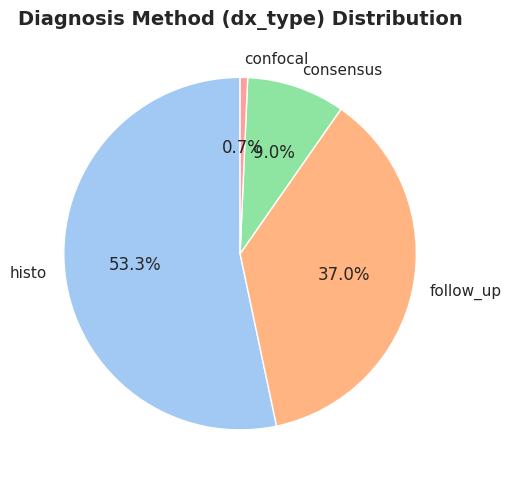


Diagnosis methods:
  histo          : 5340
  follow_up      : 3704
  consensus      : 902
  confocal       : 69


In [28]:
fig, ax = plt.subplots(figsize=(10, 5))
dx_type_counts = df['dx_type'].value_counts()
wedges, texts, autotexts = ax.pie(
    dx_type_counts.values,
    labels=dx_type_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel'),
    startangle=90
)
ax.set_title('Diagnosis Method (dx_type) Distribution', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()
print('\nDiagnosis methods:')
for k, v in dx_type_counts.items():
    print(f'  {k:15s}: {v}')


---
## 6.  Missing Value Analysis


In [29]:
print('Missing Values per Column:')
missing_vals = df.isnull().sum()
missing_pct  = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing_vals, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
if len(missing_df) == 0:
    print('  [OK] No missing values found!')
else:
    print(missing_df.to_string())

# Fill missing age with median
df['age'].fillna(df['age'].median(), inplace=True)
print(f'\nAge NaN after fill: {df["age"].isna().sum()}')


Missing Values per Column:
     Missing Count  Missing %
age             57       0.57

Age NaN after fill: 57


---
## 7.  Correlation Analysis


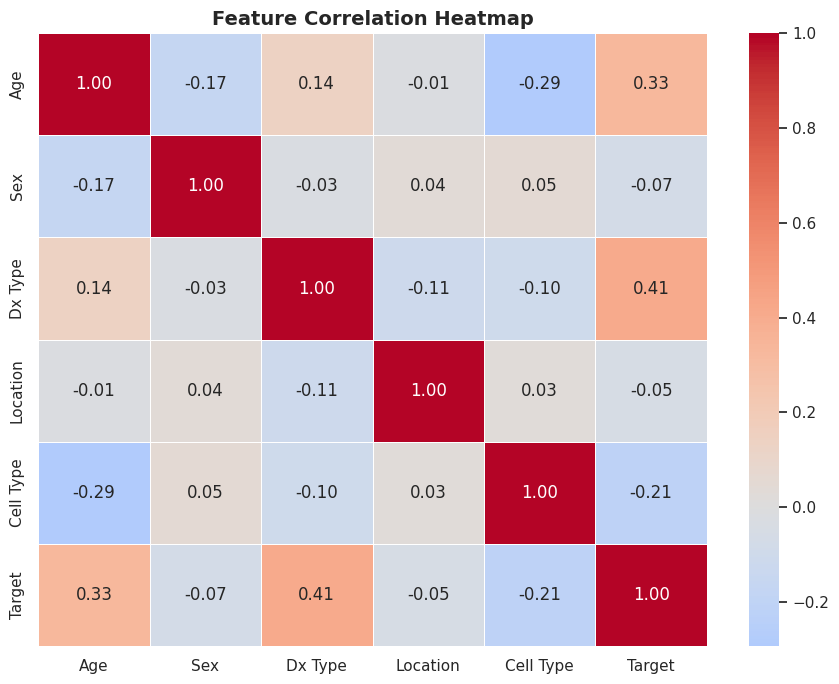

In [30]:
# Encode categorical columns for correlation
df_enc = df.copy()
df_enc['sex_enc'] = df_enc['sex'].map({'male': 0, 'female': 1, 'unknown': -1})
df_enc['dx_type_enc'] = pd.Categorical(df_enc['dx_type']).codes
df_enc['loc_enc'] = pd.Categorical(df_enc['localization']).codes

corr_cols = ['age', 'sex_enc', 'dx_type_enc', 'loc_enc', 'cell_type_idx', 'target']
corr_matrix = df_enc[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            xticklabels=['Age','Sex','Dx Type','Location','Cell Type','Target'],
            yticklabels=['Age','Sex','Dx Type','Location','Cell Type','Target'])
ax.set_title('Feature Correlation Heatmap', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()


---
## 8.  Sample Image Visualization


Valid image entries: 10015


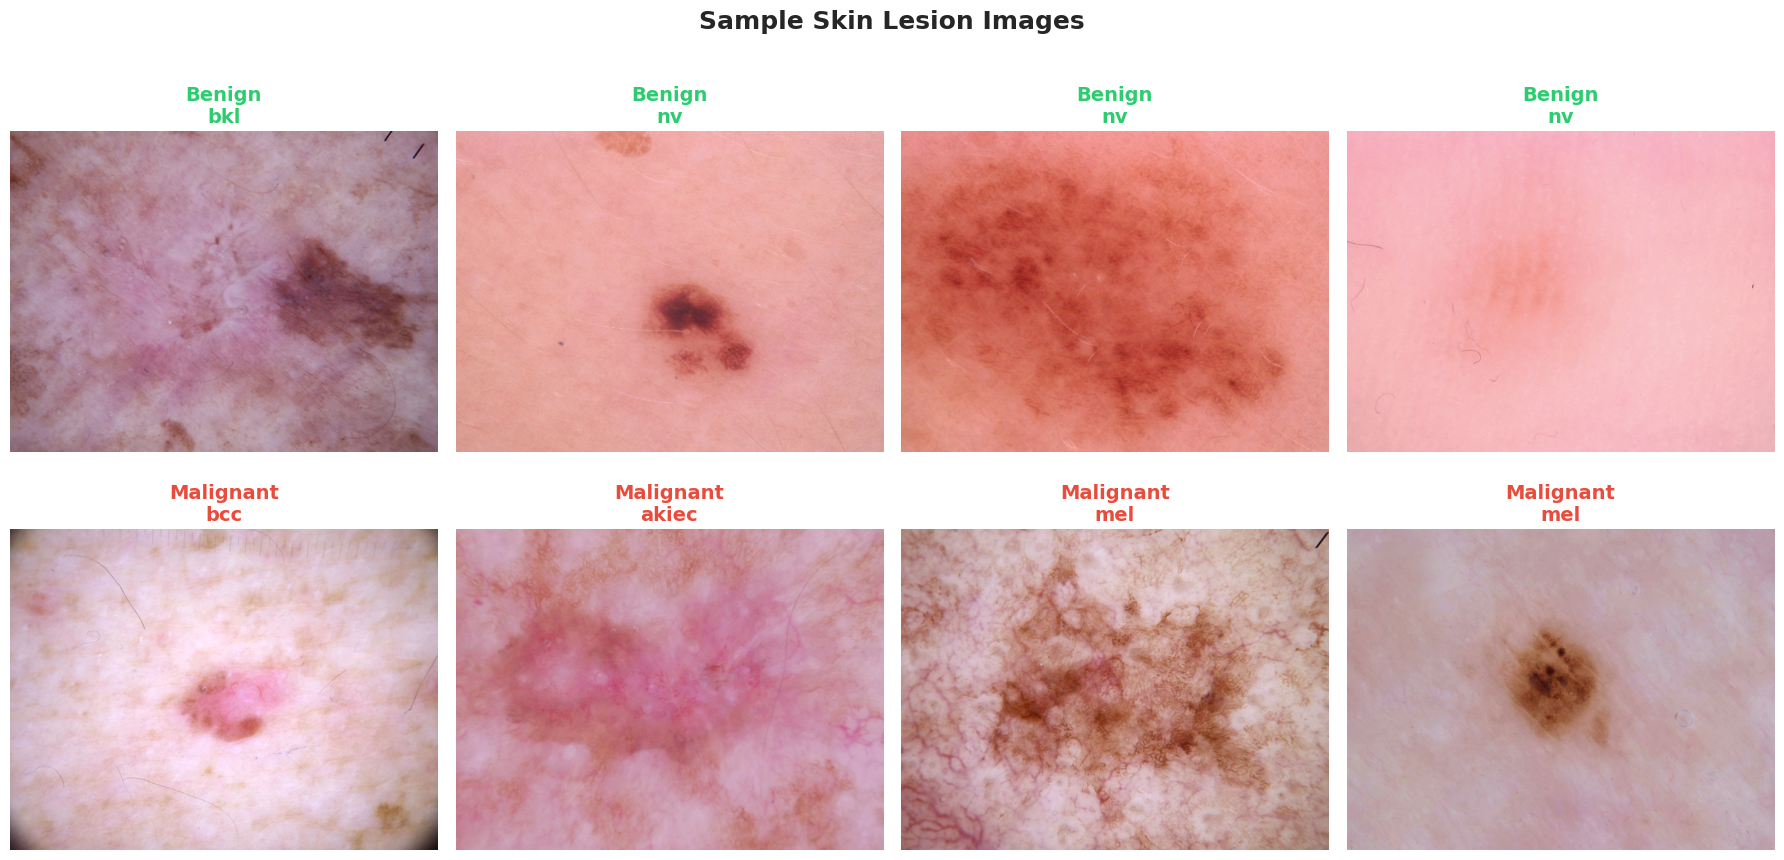

In [31]:
#  Keep only rows with valid image paths 
df_valid = df.dropna(subset=['path']).reset_index(drop=True)
print(f'Valid image entries: {len(df_valid)}')

#  Display 4 Benign + 4 Malignant samples 
benign_samples    = df_valid[df_valid['target'] == 0].sample(4, random_state=42)
malignant_samples = df_valid[df_valid['target'] == 1].sample(4, random_state=42)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Sample Skin Lesion Images', fontsize=18, fontweight='bold', y=1.01)

for i in range(4):
    # Benign row
    img_b = Image.open(benign_samples.iloc[i]['path'])
    axes[0, i].imshow(img_b)
    axes[0, i].set_title(f"Benign\n{benign_samples.iloc[i]['dx']}",
                         color='#2ecc71', fontweight='bold')
    axes[0, i].axis('off')

    # Malignant row
    img_m = Image.open(malignant_samples.iloc[i]['path'])
    axes[1, i].imshow(img_m)
    axes[1, i].set_title(f"Malignant\n{malignant_samples.iloc[i]['dx']}",
                         color='#e74c3c', fontweight='bold')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


### 8.2 Display One Sample Per Lesion Type (All 7 Classes)


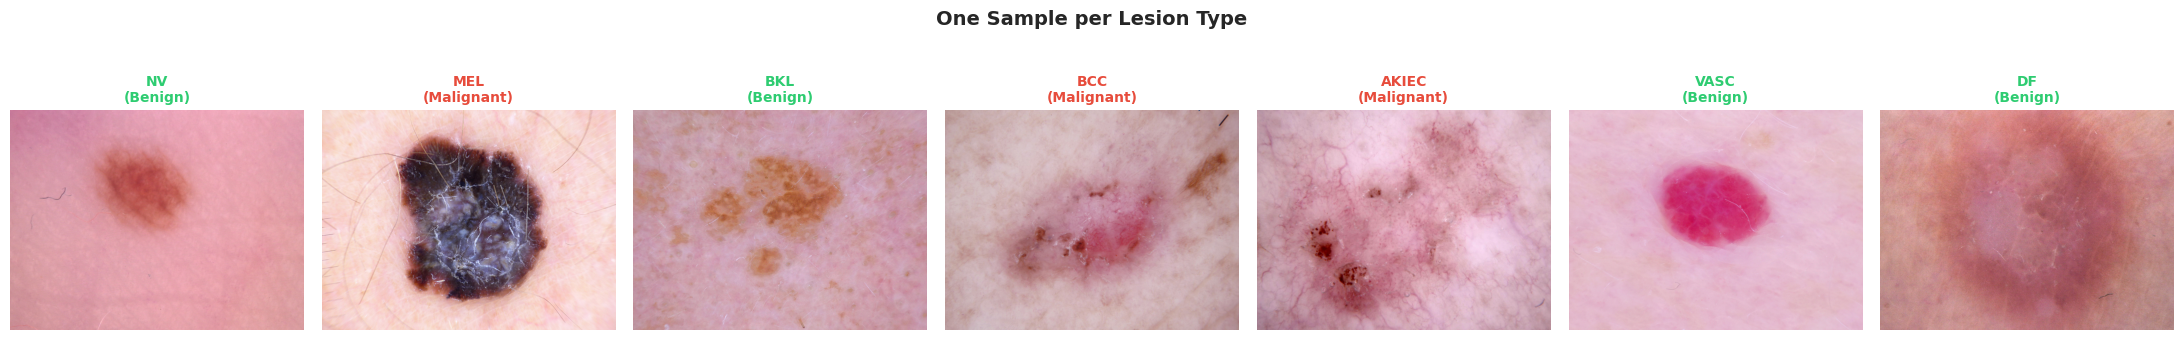

In [32]:
fig, axes = plt.subplots(1, 7, figsize=(22, 4))
all_types = list(lesion_type_dict.keys())

for i, dx_code in enumerate(all_types):
    subset = df_valid[df_valid['dx'] == dx_code]
    if len(subset) > 0:
        row = subset.sample(1, random_state=7).iloc[0]
        img = Image.open(row['path'])
        axes[i].imshow(img)
        label = 'Malignant' if row['target'] == 1 else 'Benign'
        color  = '#e74c3c' if row['target'] == 1 else '#2ecc71'
        axes[i].set_title(f"{dx_code.upper()}\n({label})", color=color, fontweight='bold', fontsize=10)
        axes[i].axis('off')

plt.suptitle('One Sample per Lesion Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 9.  Image Size Statistics


In [33]:
#  Sample 200 images and record dimensions 
sample_imgs = df_valid.sample(min(200, len(df_valid)), random_state=42)
widths, heights = [], []

for _, row in sample_imgs.iterrows():
    try:
        img = Image.open(row['path'])
        widths.append(img.width)
        heights.append(img.height)
    except Exception:
        pass

print(f'Width  — mean: {np.mean(widths):.0f}px, std: {np.std(widths):.0f}px')
print(f'Height — mean: {np.mean(heights):.0f}px, std: {np.std(heights):.0f}px')
print(f'Most images are {np.median(widths):.0f} x {np.median(heights):.0f} pixels')


Width  — mean: 600px, std: 0px
Height — mean: 450px, std: 0px
Most images are 600 x 450 pixels


---
## 10.  Key Findings Summary


In [34]:
print('=' * 65)
print('  KEY EDA FINDINGS — HAM10000 Skin Cancer Dataset')
print('=' * 65)
print(f'   Total samples     : {len(df):,}')
print(f'   Total images      : {len(df_valid):,}')
benign_pct = (df["target"] == 0).mean() * 100
malignant_pct = (df["target"] == 1).mean() * 100
print(f'   Benign samples    : {(df["target"]==0).sum():,} ({benign_pct:.1f}%)')
print(f'   Malignant samples : {(df["target"]==1).sum():,} ({malignant_pct:.1f}%)')
print(f'   Class imbalance   : ~{benign_pct/malignant_pct:.1f}:1 (Benign:Malignant)')
print(f'   Age range         : {df["age"].min():.0f} – {df["age"].max():.0f} years')
print(f'   Median age        : {df["age"].median():.0f} years')
print(f'   Gender split      : {(df["sex"]=="male").sum()} male / {(df["sex"]=="female").sum()} female')
print('   Dominant class    : Melanocytic nevi (nv)')
print('   Image resolution  : ~600 x 450 px (resized to 224x224 for DL)')
print('='*65)
print('\n  [WARN]  Class Imbalance Strategy:')
print('    • For Traditional ML   Stratified train/test split')
print('    • For Deep Learning    Data augmentation (flips, rotation)')


  KEY EDA FINDINGS — HAM10000 Skin Cancer Dataset
   Total samples     : 10,015
   Total images      : 10,015
   Benign samples    : 8,061 (80.5%)
   Malignant samples : 1,954 (19.5%)
   Class imbalance   : ~4.1:1 (Benign:Malignant)
   Age range         : 0 – 85 years
   Median age        : 50 years
   Gender split      : 5406 male / 4552 female
   Dominant class    : Melanocytic nevi (nv)
   Image resolution  : ~600 x 450 px (resized to 224x224 for DL)

  [WARN]  Class Imbalance Strategy:
    • For Traditional ML   Stratified train/test split
    • For Deep Learning    Data augmentation (flips, rotation)
